# Final Project: IMBD MOVIES
#### Authors: D. Whitney, C. Mott, B. Graeve
#### Course: CSC 5610
#### Date: 5/5/2026

### Part 1: Load and Clean Data

##### 1.1 Load Data

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


movies_df = pd.read_csv('TMDB_movie_dataset_v11.csv')

display(movies_df.head())
movies_df.info()
movies_df.describe()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1418445 non-null  int64  
 1   title                 1418427 non-null  str    
 2   vote_average          1418445 non-null  float64
 3   vote_count            1418445 non-null  int64  
 4   status                1418445 non-null  str    
 5   release_date          1103168 non-null  str    
 6   revenue               1418445 non-null  int64  
 7   runtime               1418445 non-null  int64  
 8   adult                 1418445 non-null  bool   
 9   backdrop_path         352346 non-null   str    
 10  budget                1418445 non-null  int64  
 11  homepage              145804 non-null   str    
 12  imdb_id               667862 non-null   str    
 13  original_language     1418445 non-null  str    
 14  original_title        1418427 non-null  str  

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06
mean,8.988704e+05,1.555490e+00,1.512753e+01,6.216328e+05,4.396686e+01,2.354907e+05,1.011936e+00
std,4.774842e+05,2.857763e+00,2.852197e+02,1.970374e+07,6.067686e+01,5.074687e+06,6.807757e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.946380e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.570000e-02
50%,9.219990e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.316546e+06,1.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.030000e-01
max,1.689057e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


##### 1.2 Drop unnecessary variables

In [133]:
# Drop columns that are not needed for analysis
temp_df = movies_df.drop(columns=['id', 'overview', 'original_title', 'backdrop_path', 
                                  'poster_path', 'imdb_id', 'homepage', 'status', 'tagline'])
movies_df = temp_df.copy()
movies_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 15 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   title                 1418427 non-null  str    
 1   vote_average          1418445 non-null  float64
 2   vote_count            1418445 non-null  int64  
 3   release_date          1103168 non-null  str    
 4   revenue               1418445 non-null  int64  
 5   runtime               1418445 non-null  int64  
 6   adult                 1418445 non-null  bool   
 7   budget                1418445 non-null  int64  
 8   original_language     1418445 non-null  str    
 9   popularity            1418445 non-null  float64
 10  genres                795142 non-null   str    
 11  production_companies  603869 non-null   str    
 12  production_countries  732113 non-null   str    
 13  spoken_languages      759350 non-null   str    
 14  keywords              350703 non-null   str  

##### 1.3 Helper Functions

In [134]:

def format_money(x, pos):
    '''
    Formats large numbers into human-readable strings with appropriate suffixes.
    '''
    if x >= abs(1e9):
        return f'${x * 1e-9:g}B'
    elif x >= abs(1e6):
        return f'${x*1e-6:g}M'
    elif x >= abs(1e3):
        return f'${x*1e-3:g}K'
    else:
        return f'${x:g}'

formatter = FuncFormatter(format_money)

##### 1.4 Initial Revenue Distribution

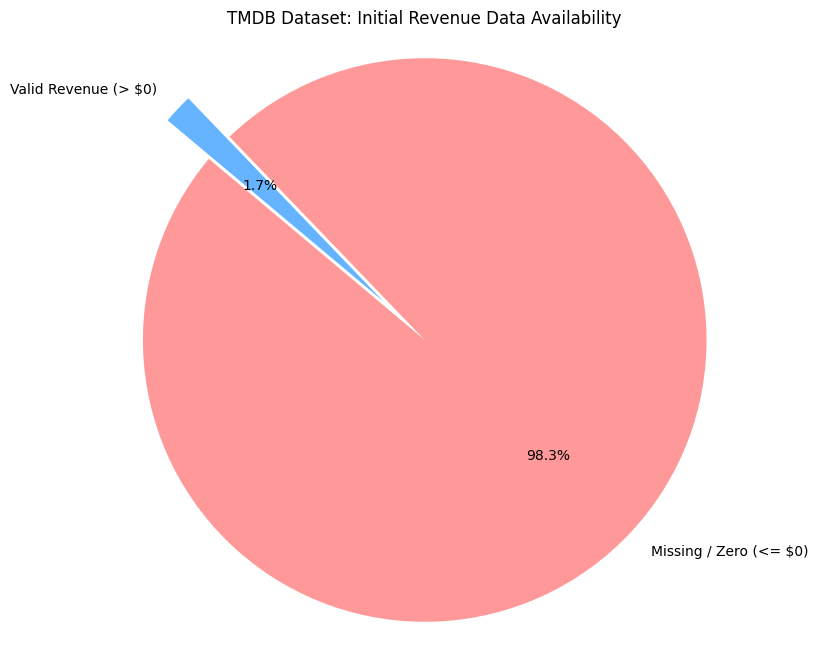

In [135]:
revenue_status = movies_df['revenue'].apply(lambda x: 'Valid Revenue (> $0)' if x > 0 else 'Missing / Zero (<= $0)')


status_counts = revenue_status.value_counts()

plt.figure(figsize=(8, 8))

explode = [0.2 if label == 'Valid Revenue (> $0)' else 0 for label in status_counts.index]

plt.pie(status_counts.values, 
        labels=status_counts.index, 
        autopct='%1.1f%%', 
        explode=explode,
        startangle=140,
        colors=['#ff9999', '#66b3ff'])

plt.title('TMDB Dataset: Initial Revenue Data Availability')
plt.axis('equal')
plt.show()

##### 1.5 Convert Datatypes and Handle Missing Data

(9832, 243)


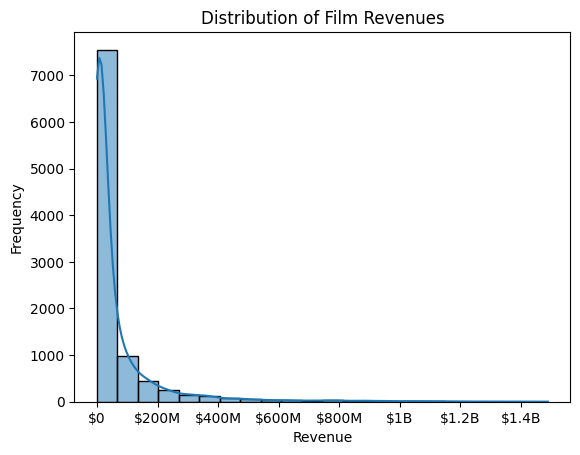

In [136]:
# Convert release_date to datetime
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

# Handle missing values and outliers in numeric columns
for col in movies_df.select_dtypes(include=['int64', 'float64']).columns:
    
    if col not in ['vote_average', 'popularity']:
        movies_df[col] = movies_df[col].replace(0, pd.NA).astype('Int64' if movies_df[col].dtype == 'int64' else 'Float64')

# Handle outliers in revenue and budget
movies_df['revenue'] = movies_df['revenue'].where((movies_df['revenue'] > 1e3) & (movies_df['revenue'] < 1.5e9), pd.NA).astype('Int64')
movies_df['budget'] = movies_df['budget'].where((movies_df['budget'] > 1e3) & (movies_df['budget'] < 1.5e9), pd.NA).astype('Int64')

# Drop rows with missing revenue values
movies_df.dropna(subset=['revenue'], inplace=True)
movies_df.reset_index(drop=True, inplace=True)


mlb = MultiLabelBinarizer(sparse_output=False)
mlb_encoded_df_list = []
non_ascii_regex = r'[^\x00-\x7F]+'

# Process categorical columns, handling both multi-label and single-label cases
for col in movies_df.select_dtypes(include=['object', 'str', 'string']).columns:
    if movies_df[col].dropna().astype(str).str.contains(',').any():
        clean_series = movies_df[col].fillna('').astype(str).str.replace(non_ascii_regex, '', regex=True).str.lower()
        clean_lists = clean_series.str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])
        
        binary_matrix = mlb.fit_transform(clean_lists)
        col_names = [f"{col}_{cls}" for cls in mlb.classes_]
        
        temp_df = pd.DataFrame(binary_matrix, columns=col_names, index=movies_df.index).astype('bool')
        mlb_encoded_df_list.append(temp_df)
    else:
        clean_series = movies_df[col].fillna('').astype(str).str.lower().str.strip()
        dummies = pd.get_dummies(clean_series, prefix=col, drop_first=True).astype('bool')
        mlb_encoded_df_list.append(dummies)

# Combine all encoded DataFrames into one
mlb_encoded_df = pd.concat(mlb_encoded_df_list, axis=1)

# Filter out categories that appear in fewer than 100 movies to reduce noise
category_counts = mlb_encoded_df.sum(axis=0)
reliable_cols = category_counts[category_counts > 100].index
mlb_encoded_df = mlb_encoded_df[reliable_cols]

# Combine the original numeric columns with the encoded categorical columns
encoded_df = pd.concat([movies_df, mlb_encoded_df], axis=1)

# Drop original categorical columns and any remaining non-numeric columns
cols_to_drop = encoded_df.select_dtypes(include=['object', 'str', 'string', 'datetime']).columns

# Create a clean DataFrame with only numeric features for analysis
clean_df = encoded_df.drop(columns=cols_to_drop)
clean_df = clean_df.dropna()

print(clean_df.shape)

ax = sns.histplot(clean_df['revenue'], bins='doane', kde=True)
ax.set_title('Distribution of Film Revenues')
ax.set_xlabel('Revenue')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(formatter)
plt.show()

### Part 2: Baseline Model

Mean Squared Error: 5000429259200708.0
Mean Absolute Percentage Error: 89.01784552698481
R^2 Score: 0.7525565466992742


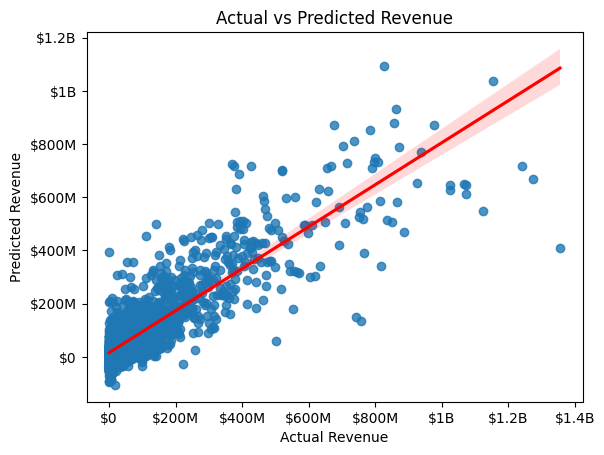

In [137]:
X = clean_df.drop(columns=['revenue'])
y = clean_df['revenue']

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.3, 
    random_state=42
)


model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R^2 Score: {r2}")


ax = sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()


### Part 3: Feature Engineering
##### 3.1 Clean and Engineer Features

(15601, 261)

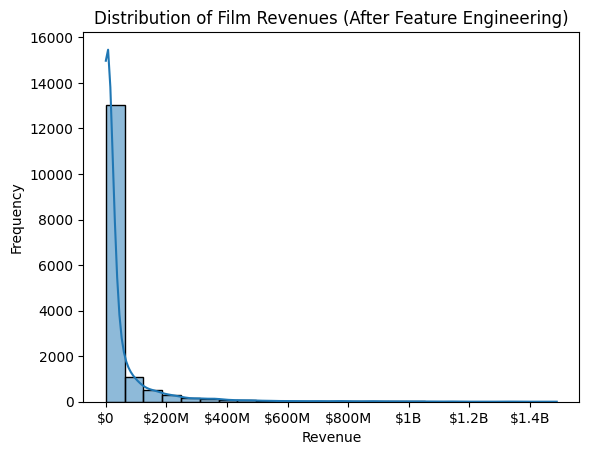

In [138]:
# Feature engineering
engineered_df = encoded_df.copy()

# Handle missing values in budget and runtime by filling with median values
median_budget = int(engineered_df['budget'].median())
engineered_df['budget'] = engineered_df['budget'].fillna(median_budget)

# Replace non-positive runtimes with NA, then fill with median runtime
engineered_df['runtime'] = engineered_df['runtime'].where(engineered_df['runtime'] > 0, pd.NA)
median_runtime = int(engineered_df['runtime'].median())
engineered_df['runtime'] = engineered_df['runtime'].fillna(median_runtime)

# Extract release month and year from release_date
engineered_df['release_month'] = engineered_df['release_date'].dt.month_name().astype('category')
engineered_df['release_year'] = engineered_df['release_date'].dt.year.astype('Int64')

# Create media format categories based on runtime
bins = [0, 40, 301, np.inf] 
labels = ['Short Film', 'Feature Film', 'TV Show/Collection']
engineered_df['media_format'] = pd.cut(
    engineered_df['runtime'], 
    bins=bins, 
    labels=labels, 
    right=False 
)


# Create new features for the number of genres, production companies, production countries, and spoken languages
engineered_df['num_genres'] = engineered_df['genres'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_production_companies'] = engineered_df['production_companies'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_production_countries'] = engineered_df['production_countries'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_spoken_languages'] = engineered_df['spoken_languages'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)

# One-hot encode the new categorical features
engineered_df = pd.get_dummies(engineered_df, columns=['media_format','release_month'], drop_first=True)

# Drop original categorical columns and any remaining non-numeric columns
cols_to_drop = engineered_df.select_dtypes(include=['object', 'str', 'string', 'datetime']).columns
engineered_df.drop(columns=cols_to_drop, inplace=True)

# Convert all numeric columns to appropriate types and handle any remaining missing values
for col in engineered_df.select_dtypes(include=['int64', 'float64']).columns:
    if engineered_df[col].dtype == 'int64':
        engineered_df[col] = engineered_df[col].astype('Int64')
    else:
        engineered_df[col] = engineered_df[col].astype('Float64')

# Drop any remaining rows with missing values after engineering
engineered_df.dropna(inplace=True)
engineered_df.reset_index(drop=True, inplace=True)


display(engineered_df.shape)

ax = sns.histplot(engineered_df['revenue'], bins='doane', kde=True)
ax.set_title('Distribution of Film Revenues (After Feature Engineering)')
ax.set_xlabel('Revenue')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(formatter)
plt.show()


##### 3.3 Feature Engineered Model

Mean Squared Error: 3564649419270149.0
Mean Absolute Percentage Error: 199.40669794976174
R^2 Score: 0.7437113305343684


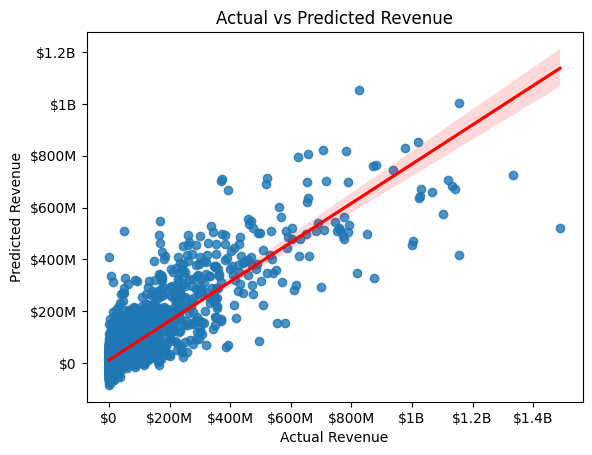

In [139]:
# Prepare data for modeling
X = engineered_df.drop(columns=['revenue'])
y = engineered_df['revenue']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a linear regression model and evaluate its performance
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R^2 Score: {r2}")

# Visualize actual vs predicted revenue
ax = sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

### Part 4: Additional Data

In [140]:
box_office_df = pd.read_csv('box_office_dataset.csv')
display(box_office_df.head())
display(box_office_df.info())
box_office_df.describe()

,rank,title,worldwide_lifetime_gross,domestic_lifetime_gross,domestic_percentage,foreign_lifetime_gross,foreign_percentage,year
0,1,Avatar,2923710708,785221649.0,26.9,2138489059,73.1,2009
1,2,Avengers: Endgame,2799439100,858373000.0,30.7,1941066100,69.3,2019
2,3,Avatar: The Way of Water,2334484620,688459501.0,29.5,1646025119,70.5,2022
3,4,Titanic,2264812968,674354882.0,29.8,1590458086,70.2,1997
4,5,Ne Zha 2,2259822417,23308176.0,1.0,2236514241,99.0,2025


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rank                      1000 non-null   str    
 1   title                     1000 non-null   str    
 2   worldwide_lifetime_gross  1000 non-null   int64  
 3   domestic_lifetime_gross   976 non-null    float64
 4   domestic_percentage       975 non-null    float64
 5   foreign_lifetime_gross    1000 non-null   int64  
 6   foreign_percentage        1000 non-null   float64
 7   year                      1000 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 82.3 KB


None

,worldwide_lifetime_gross,domestic_lifetime_gross,domestic_percentage,foreign_lifetime_gross,foreign_percentage,year
count,1.000000e+03,9.760000e+02,975.000000,1.000000e+03,1000.000000,1000.000000
mean,4.499611e+08,1.695450e+08,39.143590,2.844852e+08,61.835500,2009.593000
std,3.171869e+08,1.210795e+08,14.721182,2.273390e+08,15.770649,10.893209
min,1.947647e+08,6.752000e+03,0.100000,4.043721e+07,17.200000,1939.000000
25%,2.456947e+08,1.002277e+08,31.000000,1.419762e+08,51.575000,2003.000000
50%,3.467220e+08,1.396805e+08,39.600000,2.109980e+08,60.750000,2012.000000
75%,5.279171e+08,2.061064e+08,48.800000,3.489661e+08,69.900000,2017.000000
max,2.923711e+09,9.366622e+08,82.800000,2.236514e+09,100.000000,2026.000000


##### 4.# Model Improved with Additional Data


### Part 5: More Complex Models

Random Forest Mean Squared Error: 2970762642250920.5
Random Forest Mean Absolute Percentage Error: 79.03222444519729
Random Forest R^2 Score: 0.7864101864366282


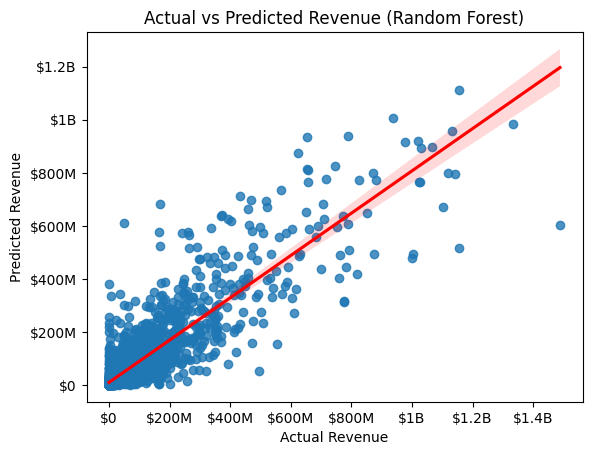

In [141]:
# Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, 
                              random_state=42)

model.fit(x_train, y_train)
y_pred_rf = model.predict(x_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf}")
print(f"Random Forest Mean Absolute Percentage Error: {mape_rf}")
print(f"Random Forest R^2 Score: {r2_rf}")

ax = sns.regplot(x=y_test, y=y_pred_rf, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue (Random Forest)")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()



### Part 6: Model Comparisons

### Part 7: Minimum Model

### Part 8: Final Analysis